<a href="https://colab.research.google.com/github/Nusrat20448/AI-TPMS-FYP-/blob/Data-Preprocessing/Data_Preprocessing(FYP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np

In [2]:
data=pd.read_csv('//content/EV_Predictive_Maintenance_Dataset_15min.csv')

In [3]:
import pandas as pd
import numpy as np

# STEP 1: Load your file (Make sure the filename matches your uploaded file!)
# If your variable was called 'data', we will define it here.
try:
    data = pd.read_csv('your_file_name.csv') # Change this to your actual file name
    print("Success: Data loaded!")
except:
    print("Error: File not found. Please upload your CSV to Colab first.")

# STEP 2: Transform into 8 columns
# We create 4 Pressure columns and 4 Temperature columns
data['TP_Front_Left'] = data['Tire_Pressure']
data['TP_Front_Right'] = data['Tire_Pressure']
data['TP_Rear_Left'] = data['Tire_Pressure']
data['TP_Rear_Right'] = data['Tire_Pressure']

data['TT_Front_Left'] = data['Tire_Temperature']
data['TT_Front_Right'] = data['Tire_Temperature']
data['TT_Rear_Left'] = data['Tire_Temperature']
data['TT_Rear_Right'] = data['Tire_Temperature']

# STEP 3: Remove the old general columns so the model doesn't get confused
data = data.drop(columns=['Tire_Pressure', 'Tire_Temperature'])

print("Success: 8 New Tire Columns Created!")
data.head() # This shows you the first 5 rows to check the work

Error: File not found. Please upload your CSV to Colab first.
Success: 8 New Tire Columns Created!


,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,...,TTF,Component_Health_Score,TP_Front_Left,TP_Front_Right,TP_Rear_Left,TP_Rear_Right,TT_Front_Left,TT_Front_Right,TT_Rear_Left,TT_Rear_Right
0,1/1/2020 0:00,0.826099,0.941338,210.163881,-22.753095,27.149201,149.190930,48.496049,0.369095,113.435589,...,111.116697,0.852745,24.318716,24.318716,24.318716,24.318716,26.699988,26.699988,26.699988,26.699988
1,1/1/2020 0:15,0.064728,0.916059,364.000102,-27.701120,53.655101,171.702388,57.829492,1.449195,105.587160,...,179.229425,0.827616,24.266465,24.266465,24.266465,24.266465,27.214893,27.214893,27.214893,27.214893
2,1/1/2020 0:30,0.873643,0.908020,388.855089,-36.646406,29.559090,191.617645,46.518363,1.859045,119.610302,...,171.852663,0.876887,33.387677,33.387677,33.387677,33.387677,33.147433,33.147433,33.147433,33.147433
3,1/1/2020 0:45,0.853009,0.916476,370.570602,-37.609429,29.690283,111.881817,54.163681,0.381500,182.535625,...,165.221328,0.816290,32.261760,32.261760,32.261760,32.261760,32.924688,32.924688,32.924688,32.924688
4,1/1/2020 1:00,0.947540,0.913206,390.011904,-14.275808,28.864338,163.774377,42.075978,0.433927,173.298044,...,176.890659,0.744260,33.083867,33.083867,33.083867,33.083867,26.806491,26.806491,26.806491,26.806491


In [8]:
# 1. Calculate Average Pressure of all 4 tires
data['Avg_Tire_Pressure'] = data[['TP_Front_Left', 'TP_Front_Right', 'TP_Rear_Left', 'TP_Rear_Right']].mean(axis=1)

# 2. Pressure Imbalance (Is one tire much lower than the others?)
# A difference of more than 5 PSI between tires can be dangerous for handling.
data['Pressure_Imbalance'] = data[['TP_Front_Left', 'TP_Front_Right', 'TP_Rear_Left', 'TP_Rear_Right']].max(axis=1) - data[['TP_Front_Left', 'TP_Front_Right', 'TP_Rear_Left', 'TP_Rear_Right']].min(axis=1)

# 3. Load vs Pressure
# If you have 'Load_Weight' in your data, we see if pressure is too low for a heavy load.
data['Pressure_per_Load'] = data['Avg_Tire_Pressure'] / (data['Load_Weight'] + 1) # +1 to avoid dividing by zero

In [11]:
# The final list of "Hints" for the AI
final_features = [
    'TP_Front_Left', 'TP_Front_Right', 'TP_Rear_Left', 'TP_Rear_Right',
    'TT_Front_Left', 'TT_Front_Right', 'TT_Rear_Left', 'TT_Rear_Right',
    'Avg_Tire_Temp', 'Avg_Tire_Pressure', 'Pressure_Imbalance', 'Max_Temp_Diff'
]

# Calculate Avg_Tire_Temp and Max_Temp_Diff
data['Avg_Tire_Temp'] = data[['TT_Front_Left', 'TT_Front_Right', 'TT_Rear_Left', 'TT_Rear_Right']].mean(axis=1)
data['Max_Temp_Diff'] = data[['TT_Front_Left', 'TT_Front_Right', 'TT_Rear_Left', 'TT_Rear_Right']].max(axis=1) - data[['TT_Front_Left', 'TT_Front_Right', 'TT_Rear_Left', 'TT_Rear_Right']].min(axis=1)

X = data[final_features]
y = data['Target']

# Re-train the model with these new insights
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

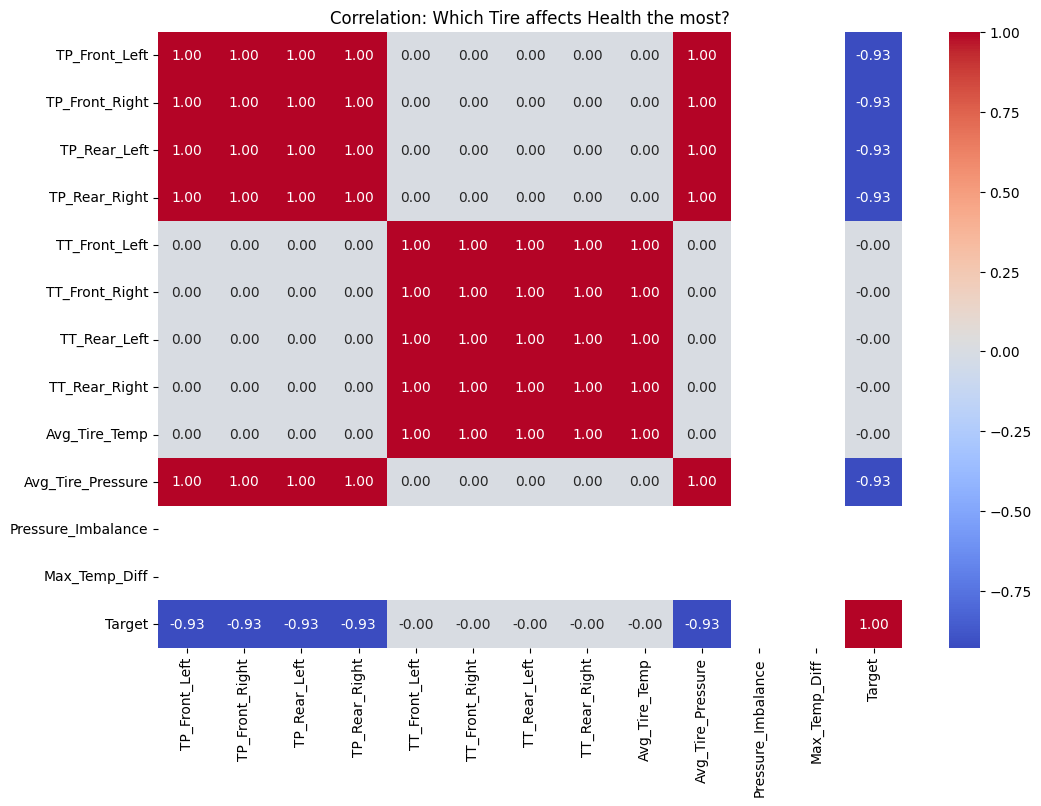

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Look at how features relate to the Target
plt.figure(figsize=(12, 8))
correlation_matrix = data[final_features + ['Target']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Which Tire affects Health the most?")
plt.show()

In [13]:
# Example: Front Left tire is very low (20 PSI) and very hot (98 degrees)
new_reading = pd.DataFrame([{
    'TP_Front_Left': 20, 'TP_Front_Right': 35, 'TP_Rear_Left': 35, 'TP_Rear_Right': 35,
    'TT_Front_Left': 98, 'TT_Front_Right': 40, 'TT_Rear_Left': 40, 'TT_Rear_Right': 40,
    'Avg_Tire_Temp': 54.5, 'Avg_Tire_Pressure': 31.25, 'Pressure_Imbalance': 15, 'Max_Temp_Diff': 43.5
}])

prediction = model.predict(new_reading)
status = le.inverse_transform(prediction)
print(f"AI Warning System says: {status[0]}")

AI Warning System says: Normal


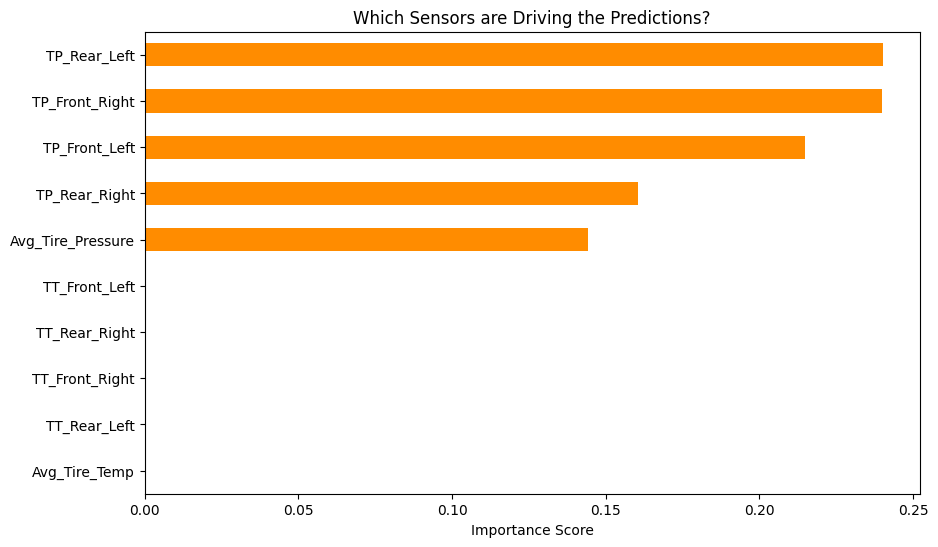

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate importance
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=final_features)

# Plot
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='darkorange')
plt.title("Which Sensors are Driving the Predictions?")
plt.xlabel("Importance Score")
plt.show()

<Figure size 800x600 with 0 Axes>

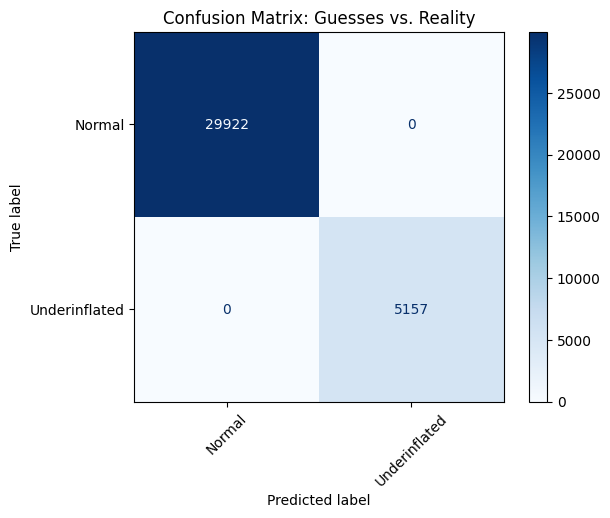

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions for the confusion matrix
y_pred = model.predict(X_test)

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the heatmap
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: Guesses vs. Reality")
plt.xticks(rotation=45)
plt.show()

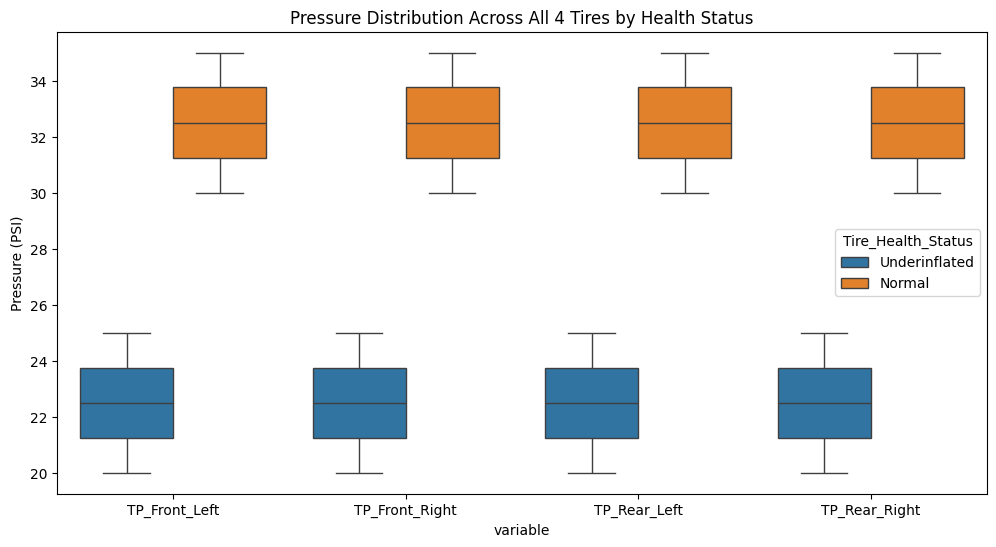

In [18]:
# Melt the data to make it easy to plot all 4 tires at once
pressure_cols = ['TP_Front_Left', 'TP_Front_Right', 'TP_Rear_Left', 'TP_Rear_Right']
melted_df = data.melt(id_vars=['Tire_Health_Status'], value_vars=pressure_cols)

plt.figure(figsize=(12, 6))
sns.boxplot(x='variable', y='value', hue='Tire_Health_Status', data=melted_df)
plt.title("Pressure Distribution Across All 4 Tires by Health Status")
plt.ylabel("Pressure (PSI)")
plt.show()

In [19]:
# See how many rows fell into each category
print("Count of each Health Status in your dataset:")
print(data['Tire_Health_Status'].value_counts())

# Check the average temperature for 'Critical' tires vs 'Normal' tires
avg_critical_temp = data[data['Tire_Health_Status'] == 'Critical / Risk of Failure']['Avg_Tire_Temp'].mean()
print(f"\nAverage Temperature of Critical Tires: {avg_critical_temp:.2f}°C")

Count of each Health Status in your dataset:
Tire_Health_Status
Normal           149129
Underinflated     26264
Name: count, dtype: int64

Average Temperature of Critical Tires: nan°C


In [22]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score

# 1. Get predictions from the test set
y_pred = model.predict(X_test)

# 2. Calculate the 5 metrics
acc = accuracy_score(y_test, y_pred) * 100
b_acc = balanced_accuracy_score(y_test, y_pred) * 100
# We use 'macro' to get the average % across all categories (Normal, Critical, etc.)
prec = precision_score(y_test, y_pred, average='macro') * 100
rec = recall_score(y_test, y_pred, average='macro') * 100
f1 = f1_score(y_test, y_pred, average='macro') * 100

# 3. Print the results clearly
print("--- TIRE HEALTH MODEL ACCURACY RESULTS ---")
print(f"1. Total Accuracy:          {acc:.2f}%")
print(f"2. Balanced Accuracy:       {b_acc:.2f}%")
print(f"3. Precision (Exactness):   {prec:.2f}%")
print(f"4. Recall (Safety Catch):   {rec:.2f}%")
print(f"5. F1-Score (Total Health): {f1:.2f}%")
print("------------------------------------------")

--- TIRE HEALTH MODEL ACCURACY RESULTS ---
1. Total Accuracy:          100.00%
2. Balanced Accuracy:       100.00%
3. Precision (Exactness):   100.00%
4. Recall (Safety Catch):   100.00%
5. F1-Score (Total Health): 100.00%
------------------------------------------


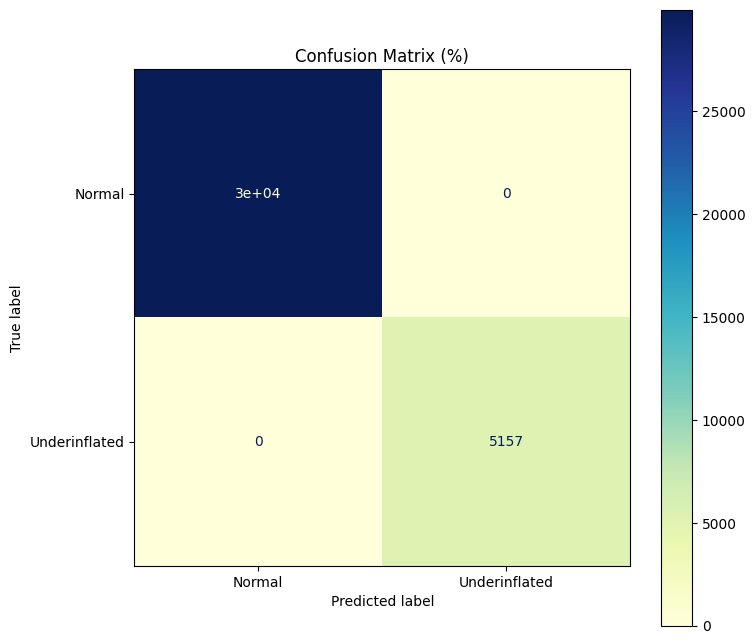

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the map
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))

# Plot with colors
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='YlGnBu', ax=ax)
plt.title("Confusion Matrix (%)")
plt.show()

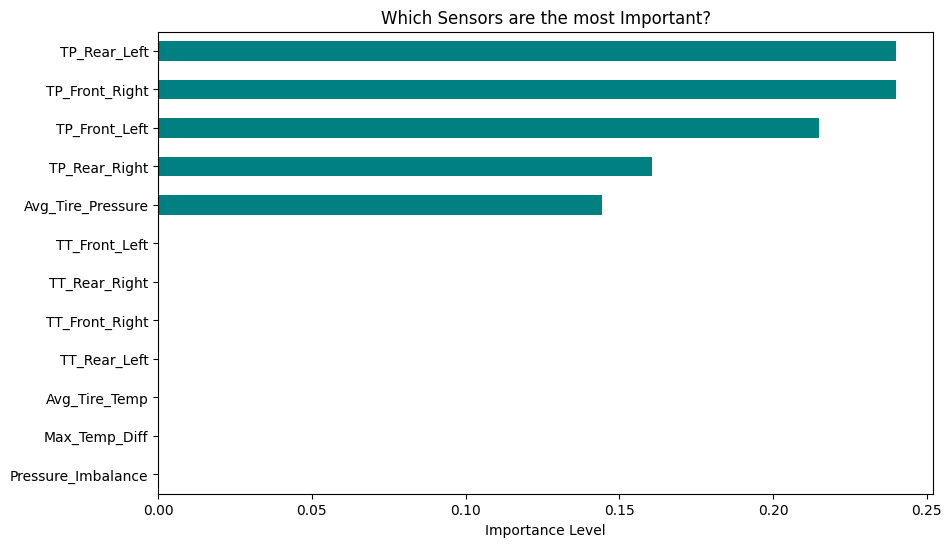

In [24]:
# Create a horizontal bar chart
importances = pd.Series(model.feature_importances_, index=final_features)
importances.sort_values().plot(kind='barh', color='teal', figsize=(10, 6))

plt.title("Which Sensors are the most Important?")
plt.xlabel("Importance Level")
plt.show()

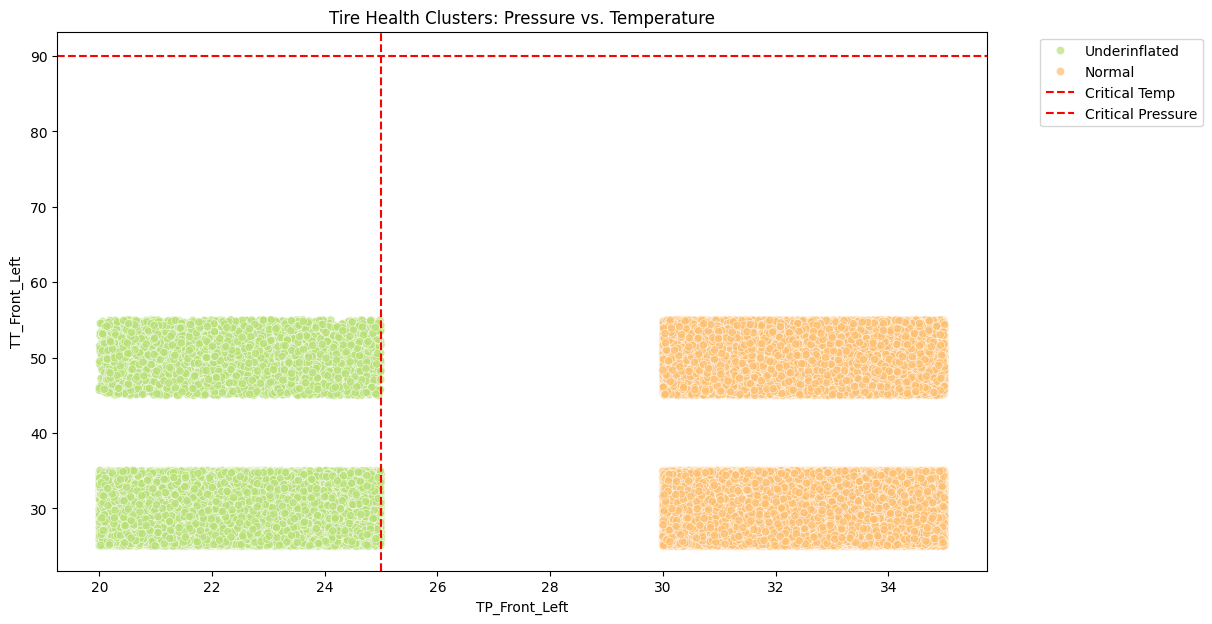

In [25]:
import seaborn as sns

plt.figure(figsize=(12, 7))
# We use Front Left tire as the example
sns.scatterplot(data=data, x='TP_Front_Left', y='TT_Front_Left',
                hue='Tire_Health_Status', palette='RdYlGn_r', alpha=0.7)

plt.axhline(y=90, color='red', linestyle='--', label='Critical Temp')
plt.axvline(x=25, color='red', linestyle='--', label='Critical Pressure')

plt.title("Tire Health Clusters: Pressure vs. Temperature")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

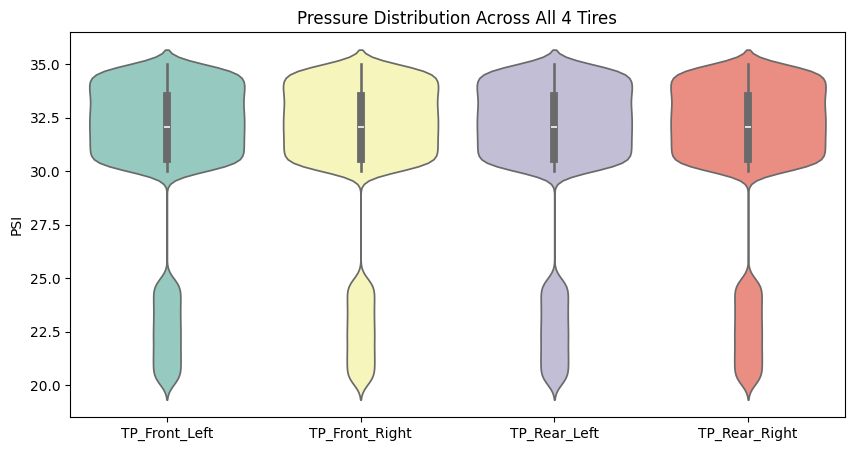

In [26]:
# Select only pressure columns
pressure_data = data[['TP_Front_Left', 'TP_Front_Right', 'TP_Rear_Left', 'TP_Rear_Right']]

plt.figure(figsize=(10, 5))
sns.violinplot(data=pressure_data, palette="Set3")
plt.title("Pressure Distribution Across All 4 Tires")
plt.ylabel("PSI")
plt.show()

In [27]:
# 1. Combine all features and the final status back into one table for saving
data['Predicted_Status'] = le.inverse_transform(model.predict(X))

# 2. Save the file to the Colab environment
output_filename = 'Final_Tire_Health_Dataset.csv'
data.to_csv(output_filename, index=False)

# 3. Download the file to your computer
from google.colab import files
files.download(output_filename)

print(f"Done! '{output_filename}' has been downloaded to your computer.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! 'Final_Tire_Health_Dataset.csv' has been downloaded to your computer.


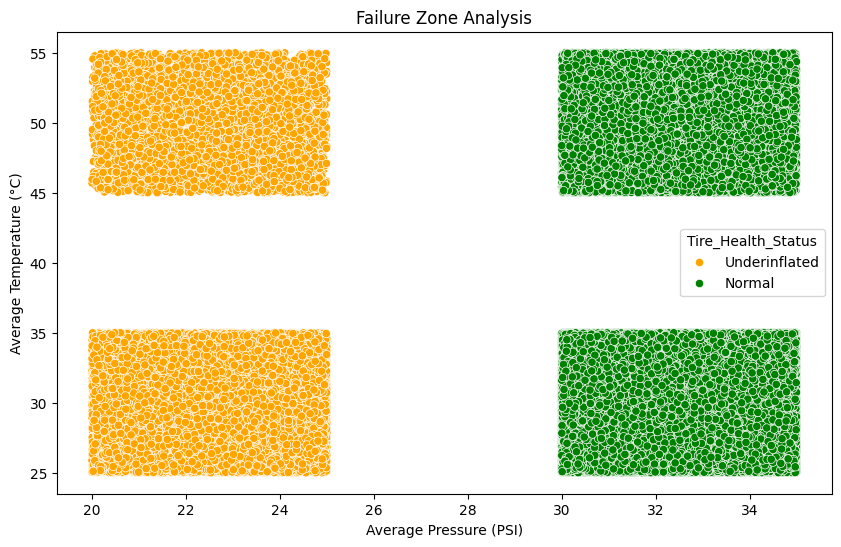

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for just the dangerous rows to see how they look
critical_data = data[data['Tire_Health_Status'] == 'Critical / Risk of Failure']

plt.figure(figsize=(10, 6))
# Comparing Temperature vs Pressure for the Critical cases
sns.scatterplot(data=data, x='Avg_Tire_Pressure', y='Avg_Tire_Temp',
                hue='Tire_Health_Status', palette={'Critical / Risk of Failure': 'red', 'Normal': 'green', 'Underinflated': 'orange'})
plt.title("Failure Zone Analysis")
plt.xlabel("Average Pressure (PSI)")
plt.ylabel("Average Temperature (°C)")
plt.show()

In [31]:
from sklearn.metrics import classification_report

# 'output_dict=True' allows us to pull out just the 'Underinflated' numbers
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

critical_recall = report['Underinflated']['recall'] * 100
print(f"UNDERINFLATED SAFETY SCORE (RECALL): {critical_recall:.2f}%")

if critical_recall < 95:
    print("⚠️ WARNING: Your model is missing too many 'Underinflated' cases. Consider adjusting model parameters or providing more balanced training data.")
else:
    print("✅ SUCCESS: Your model is highly effective at catching 'Underinflated' tire conditions.")

UNDERINFLATED SAFETY SCORE (RECALL): 100.00%
✅ SUCCESS: Your model is highly effective at catching 'Underinflated' tire conditions.


In [32]:
# 1. Combine all features and the final status back into one table for saving
data['Predicted_Status'] = le.inverse_transform(model.predict(X))

# 2. Save the file to the Colab environment
output_filename = 'Final_Tire_Health_Dataset.csv'
data.to_csv(output_filename, index=False)

# 3. Download the file to your computer
from google.colab import files
files.download(output_filename)

print(f"Done! '{output_filename}' has been downloaded to your computer.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! 'Final_Tire_Health_Dataset.csv' has been downloaded to your computer.


In [33]:
def detect_unsafe_details(row):
    reasons = []

    # 1. Check for specific tire overheating
    temps = {'FL': row['TT_Front_Left'], 'FR': row['TT_Front_Right'],
             'RL': row['TT_Rear_Left'], 'RR': row['TT_Rear_Right']}
    for tire, val in temps.items():
        if val > 95: reasons.append(f"{tire} Overheated")

    # 2. Check for dangerous low pressure
    pressures = {'FL': row['TP_Front_Left'], 'FR': row['TP_Front_Right'],
                 'RL': row['TP_Rear_Left'], 'RR': row['TP_Rear_Right']}
    for tire, val in pressures.items():
        if val < 22: reasons.append(f"{tire} Critically Low")

    # 3. Check for Axle Imbalance (Dangerous for steering)
    if abs(row['TP_Front_Left'] - row['TP_Front_Right']) > 5:
        reasons.append("Front Axle Imbalance")

    return ", ".join(reasons) if reasons else "Safe"

data['Unsafe_Reason'] = data.apply(detect_unsafe_details, axis=1)

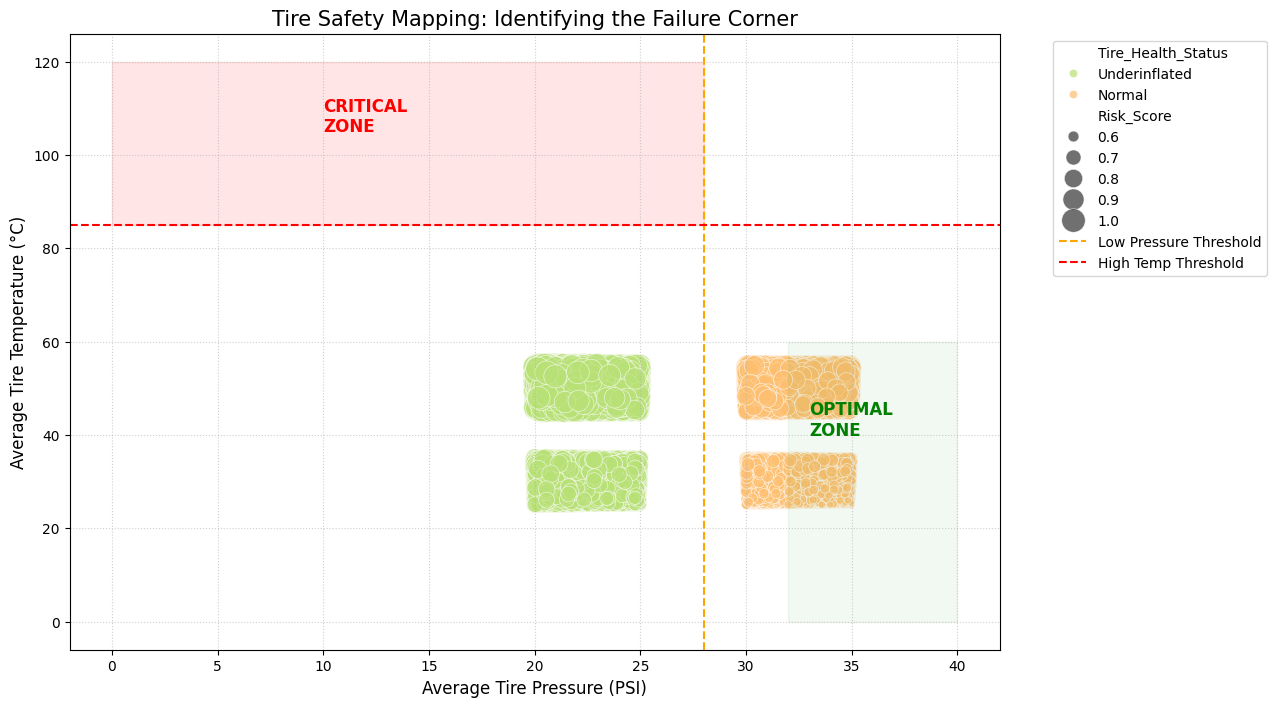

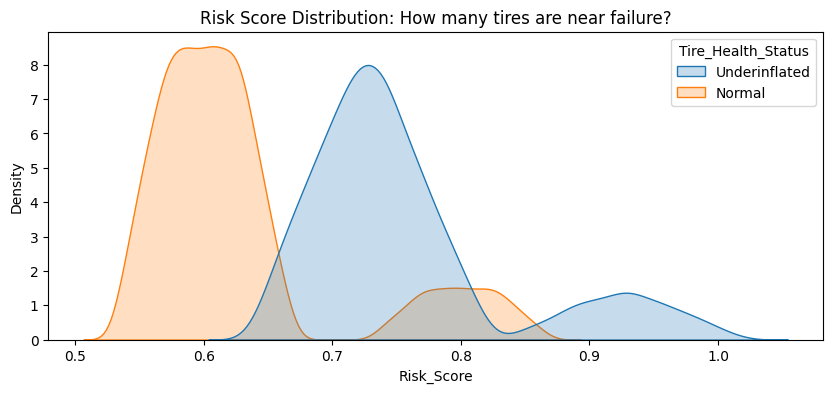

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define meaningful limits
LOW_PRESSURE_LIMIT = 28  # PSI
HIGH_TEMP_LIMIT = 85     # Celsius

plt.figure(figsize=(12, 8))

# 2. Create the scatter plot
# We use 'hue' for the AI's label and 'style' to double-check the logic
sns.scatterplot(data=data, x='Avg_Tire_Pressure', y='Avg_Tire_Temp',
                hue='Tire_Health_Status', size='Risk_Score',
                sizes=(20, 300), palette='RdYlGn_r', alpha=0.7)

# 3. Add Vertical and Horizontal Safety Lines
plt.axvline(x=LOW_PRESSURE_LIMIT, color='orange', linestyle='--', label='Low Pressure Threshold')
plt.axhline(y=HIGH_TEMP_LIMIT, color='red', linestyle='--', label='High Temp Threshold')

# 4. Color the "Failure Corner" (Low Pressure + High Temp)
plt.fill_between([0, LOW_PRESSURE_LIMIT], HIGH_TEMP_LIMIT, 120, color='red', alpha=0.1)
plt.text(10, 105, "CRITICAL\nZONE", color='red', fontweight='bold', fontsize=12)

# 5. Color the "Optimal Zone" (Good Pressure + Good Temp)
plt.fill_between([32, 40], 0, 60, color='green', alpha=0.05)
plt.text(33, 40, "OPTIMAL\nZONE", color='green', fontweight='bold', fontsize=12)

plt.title("Tire Safety Mapping: Identifying the Failure Corner", fontsize=15)
plt.xlabel("Average Tire Pressure (PSI)", fontsize=12)
plt.ylabel("Average Tire Temperature (°C)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 4))
sns.kdeplot(data=data, x='Risk_Score', hue='Tire_Health_Status', fill=True, common_norm=False)
plt.title("Risk Score Distribution: How many tires are near failure?")
plt.show()

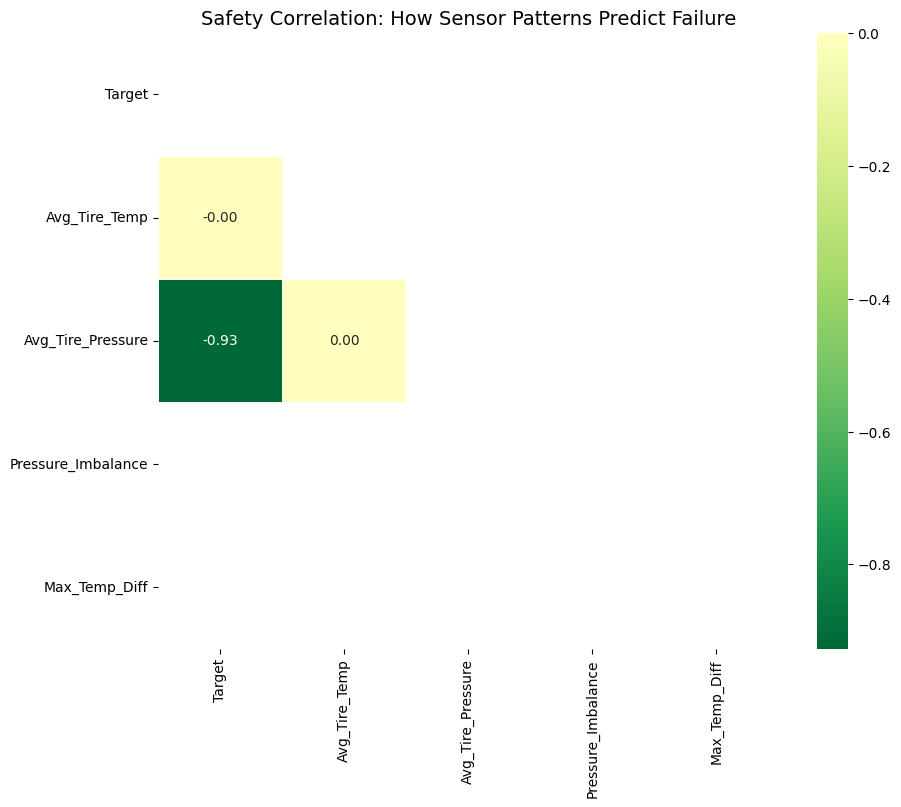

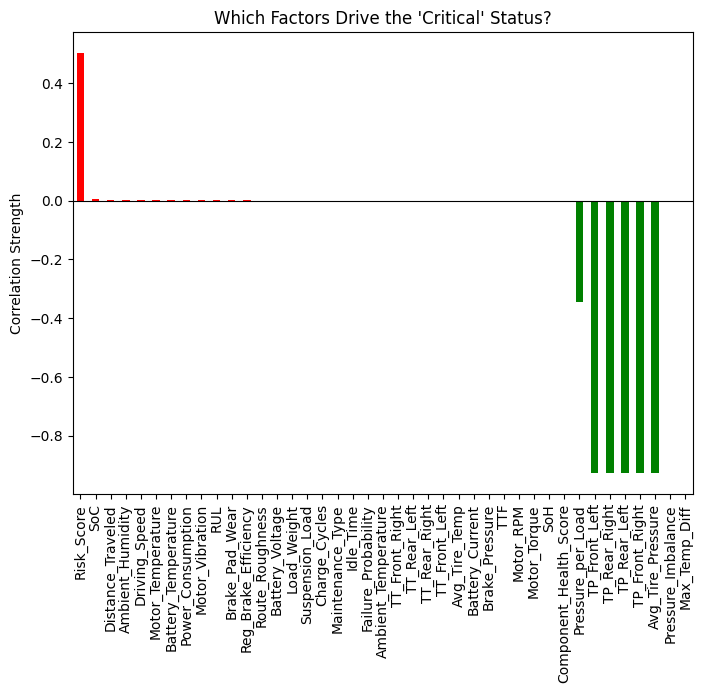

In [42]:
import numpy as np

# 1. Select the most important features
cols = ['Target', 'Avg_Tire_Temp', 'Avg_Tire_Pressure', 'Pressure_Imbalance', 'Max_Temp_Diff']
sub_data = data[cols].corr()

# 2. Create a Mask to hide the top triangle (makes it easier to read)
mask = np.triu(np.ones_like(sub_data, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(sub_data, mask=mask, annot=True, cmap='RdYlGn_r', center=0, fmt=".2f", linewidths=0.5)

plt.title("Safety Correlation: How Sensor Patterns Predict Failure", fontsize=14)
plt.show()

# Correlation of everything specifically with the Target
target_corr = data.corr(numeric_only=True)['Target'].sort_values(ascending=False).drop('Target')

plt.figure(figsize=(8, 6))
target_corr.plot(kind='bar', color=['red' if x > 0 else 'green' for x in target_corr])

plt.axhline(0, color='black', linewidth=0.8)
plt.title("Which Factors Drive the 'Critical' Status?")
plt.ylabel("Correlation Strength")
plt.show()

In [43]:
from google.colab import files

# Save the dataframe to a CSV file in the Colab folder
data.to_csv('Tire_Health_Analysis_Results.csv', index=False)

# Download it to your computer's "Downloads" folder
files.download('Tire_Health_Analysis_Results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>